## Importing the Necessary Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
from warnings import filterwarnings
filterwarnings('ignore')

## Loading the Dataset

In [4]:
df = pd.read_csv('Social_Network_Ads.csv')
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


## Basic Info of the Dataset

In [7]:
df.shape

(400, 5)

In [9]:
df.Purchased.value_counts()

Purchased
0    257
1    143
Name: count, dtype: int64

#### The Target Variable is not balanced, so actually to oversample or undersample the Target Variable in this case

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [14]:
df.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


In [16]:
df.describe(include = ['O'])

,Gender
count,400
unique,2
top,Female
freq,204


In [18]:
df.Gender.value_counts()

Gender
Female    204
Male      196
Name: count, dtype: int64

## Encoding the Gender Column

In [21]:
from sklearn.preprocessing import LabelEncoder

In [23]:
Encoder = LabelEncoder()
encoded_gender = Encoder.fit_transform(df.loc[:, 'Gender'])
encoded_gender

array([1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0,
       1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0,
       1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0,
       1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1,
       0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0,

In [25]:
df['Gender'] = encoded_gender
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,1,19,19000,0
1,15810944,1,35,20000,0
2,15668575,0,26,43000,0
3,15603246,0,27,57000,0
4,15804002,1,19,76000,0


## Correlation

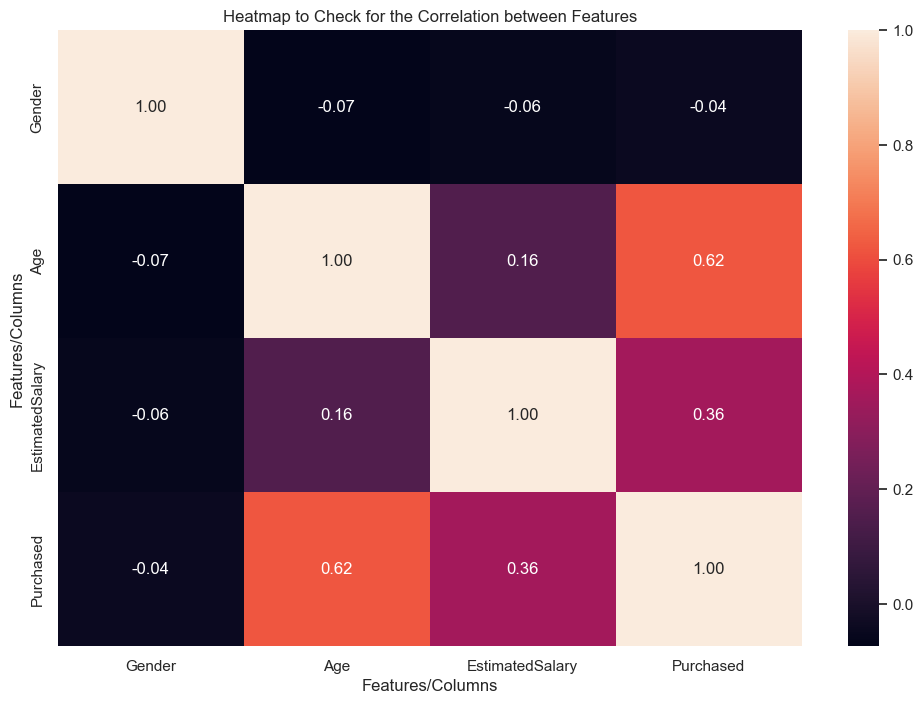

In [28]:
plt.figure(figsize = (12, 8))
sns.heatmap(df.iloc[:, 1:].corr(), annot = True, fmt = '.2f')
plt.xlabel('Features/Columns')
plt.ylabel('Features/Columns')
plt.title('Heatmap to Check for the Correlation between Features')
plt.show()

## Train Test Split

In [31]:
from sklearn.model_selection import train_test_split

In [33]:
x_train, x_test, y_train, y_test = train_test_split(df.iloc[:,[1,2,3]], df['Purchased'], test_size = 1/3, random_state = 32)

## Feature Scaling

In [38]:
from sklearn.preprocessing import StandardScaler

In [40]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)

In [42]:
x_test = scaler.transform(x_test)

## Logistic Regression Model

In [45]:
from sklearn.linear_model import LogisticRegression

In [47]:
log_model = LogisticRegression(random_state = 0)
log_model.fit(x_train, y_train)

LogisticRegression(random_state=0)

In [49]:
pred = log_model.predict(x_test)

## Evaluation

In [51]:
pred

array([1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0,
       1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0,
       0, 0], dtype=int64)

In [61]:
y_test

223    1
145    0
146    1
366    1
268    1
      ..
254    0
170    0
80     0
28     0
115    0
Name: Purchased, Length: 134, dtype: int64

In [68]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score

In [76]:
conf = confusion_matrix(y_test, pred)
print(conf)

[[73  8]
 [14 39]]


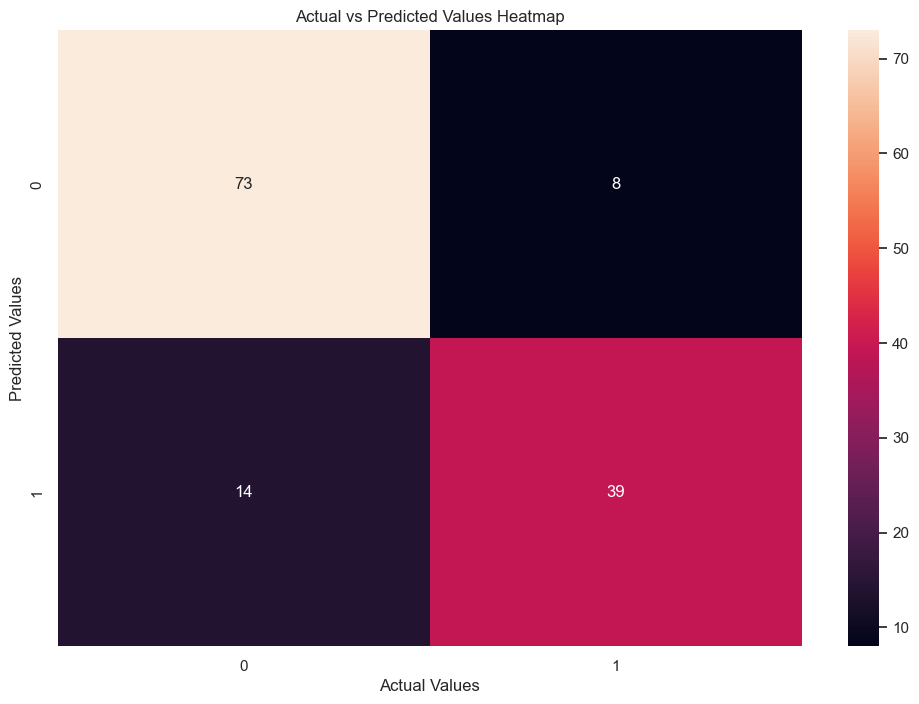

In [82]:
plt.figure(figsize = (12, 8))
sns.heatmap(conf, annot = True, fmt = 'd')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values Heatmap')
plt.show()

In [74]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87        81
           1       0.83      0.74      0.78        53

    accuracy                           0.84       134
   macro avg       0.83      0.82      0.82       134
weighted avg       0.84      0.84      0.83       134



In [88]:
print('Accuracy Score for the Model is:', accuracy_score(y_test, pred), sep = '\t')
print('Precision Score for the Model is:', precision_score(y_test, pred), sep = '\t')
print('Recall Score for the Model is:', recall_score(y_test, pred), sep = '\t')

Accuracy Score for the Model is:	0.835820895522388
Precision Score for the Model is:	0.8297872340425532
Recall Score for the Model is:	0.7358490566037735


#### Visualizing the Training Set

In [98]:
from matplotlib.colors import ListedColormap

## ROC and AUC

In [106]:
from sklearn.metrics import roc_curve, roc_auc_score

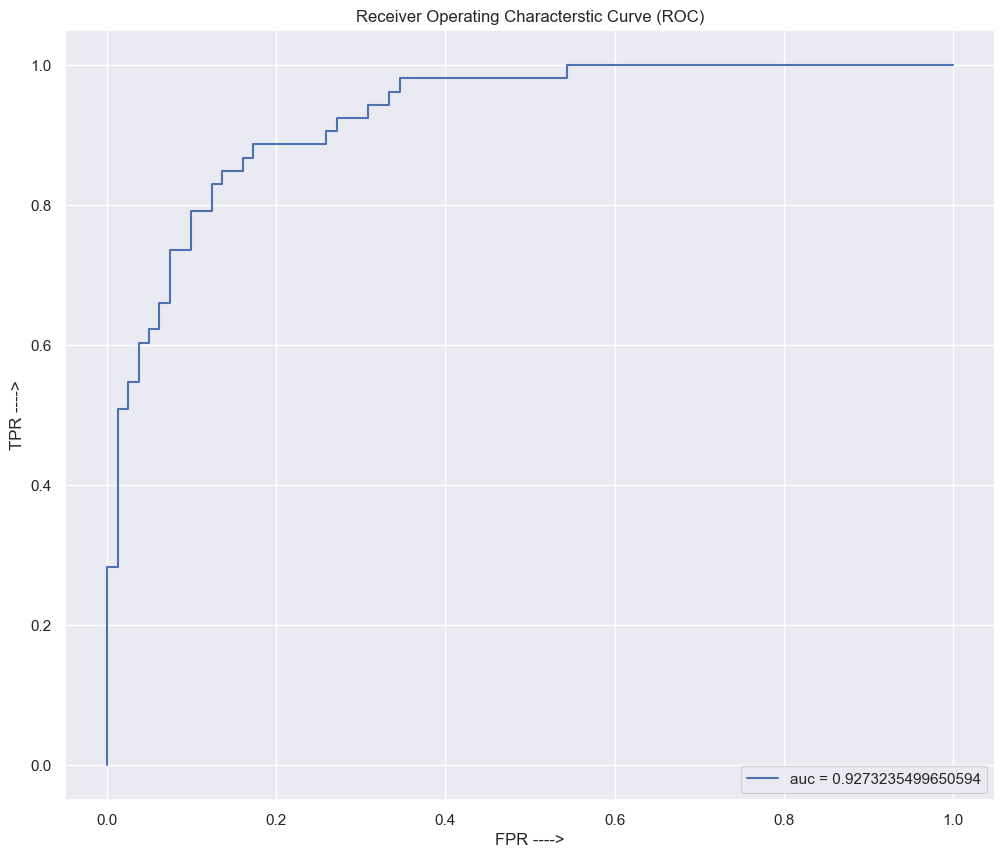

In [122]:
pred_proba = log_model.predict_proba(x_test)[::,1]
fpr, tpr, _ = roc_curve(y_test, pred_proba)
auc = roc_auc_score(y_test, pred_proba)
plt.figure(figsize=(12,10))
plt.plot(fpr, tpr, label = 'auc = '+str(auc))
plt.legend(loc = 4)
plt.title('Receiver Operating Characterstic Curve (ROC)')
plt.xlabel('FPR ---->')
plt.ylabel('TPR ---->')
plt.show()

#### Since Value of Area Under Curve (AUC) is pretty high, it is a good model